<a href="https://colab.research.google.com/github/Ruthwikau18/CodSoft_04/blob/main/CodSoft_Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CODSOFT TASK 4 - CUSTOMER SEGMENTATION

CUSTOMER PURCHASING BEHAVIOR ANALYSIS

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("CodSoft_Task_4_Customer_Segmentation (3).csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 500
Columns: 13


In [ ]:
display(df.head())


,Customer_ID,Age,Gender,Location,Product_Category,Purchase_Frequency,Number_of_Orders,Average_Order_Value,Total_Spend,Days_Since_Last_Purchase,Age_Group,Spend_Band,Customer_Value
0,CUST0001,56,Female,Mumbai,Electronics,High,18,6216,111888,99,46-60,Very High,High Value
1,CUST0002,46,Male,Chennai,Home & Kitchen,Low,3,2826,8478,143,46-60,Low,Low Value
2,CUST0003,32,Female,Mumbai,Clothing,Medium,8,3172,25376,85,26-35,Medium,Medium Value
3,CUST0004,60,Male,Pune,Beauty,Medium,5,844,4220,65,46-60,Low,Low Value
4,CUST0005,25,Male,Chennai,Clothing,Medium,5,3357,16785,132,18-25,Medium,Medium Value


In [ ]:
df.info()
print(df.isnull().sum())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Customer_ID               500 non-null    object
 1   Age                       500 non-null    int64 
 2   Gender                    500 non-null    object
 3   Location                  500 non-null    object
 4   Product_Category          500 non-null    object
 5   Purchase_Frequency        500 non-null    object
 6   Number_of_Orders          500 non-null    int64 
 7   Average_Order_Value       500 non-null    int64 
 8   Total_Spend               500 non-null    int64 
 9   Days_Since_Last_Purchase  500 non-null    int64 
 10  Age_Group                 500 non-null    object
 11  Spend_Band                500 non-null    object
 12  Customer_Value            500 non-null    object
dtypes: int64(5), object(8)
memory usage: 50.9+ KB
Customer_ID                 0
Age 

,Age,Number_of_Orders,Average_Order_Value,Total_Spend,Days_Since_Last_Purchase
count,500.000000,500.000000,500.00000,500.000000,500.000000
mean,39.506000,6.868000,3339.05200,23365.250000,92.532000
std,12.368505,5.106734,1990.55049,24890.407161,51.824285
min,18.000000,1.000000,500.00000,558.000000,1.000000
25%,29.000000,3.000000,1790.00000,6605.000000,51.000000
50%,41.000000,6.000000,2912.50000,15896.000000,91.500000
75%,50.000000,8.000000,4378.75000,30186.750000,140.000000
max,60.000000,20.000000,8951.00000,168980.000000,180.000000


In [ ]:
print(df["Age_Group"].value_counts())
print(df["Location"].value_counts())
print(df["Purchase_Frequency"].value_counts())
print(df["Spend_Band"].value_counts())

Age_Group
46-60    185
36-45    126
18-25     96
26-35     93
Name: count, dtype: int64
Location
Bengaluru    120
Mumbai        87
Delhi         83
Hyderabad     73
Pune          71
Chennai       66
Name: count, dtype: int64
Purchase_Frequency
Medium    234
Low       146
High      120
Name: count, dtype: int64
Spend_Band
Low          188
Medium       187
High          85
Very High     40
Name: count, dtype: int64


In [ ]:
location_spend = df.groupby("Location")["Total_Spend"].sum().sort_values(ascending=False)
print(location_spend)

age_spend = df.groupby("Age_Group")["Total_Spend"].sum().sort_values(ascending=False)
print(age_spend)

category_spend = df.groupby("Product_Category")["Total_Spend"].sum().sort_values(ascending=False)
print(category_spend)

Location
Mumbai       2318040
Bengaluru    2312265
Delhi        2054721
Hyderabad    1837660
Pune         1595814
Chennai      1564125
Name: Total_Spend, dtype: int64
Age_Group
46-60    4443086
36-45    2850488
18-25    2409066
26-35    1979985
Name: Total_Spend, dtype: int64
Product_Category
Electronics       5337498
Home & Kitchen    2692056
Sports            1476696
Clothing          1432704
Beauty             743671
Name: Total_Spend, dtype: int64


CUSTOMER VALUE ANALYSIS

In [ ]:
customer_value = df.groupby("Customer_Value").agg(
    Customers=("Customer_ID", "count"),
    Total_Spend=("Total_Spend", "sum"),
    Average_Spend=("Total_Spend", "mean")
).sort_values("Total_Spend", ascending=False)

display(customer_value)

,Customers,Total_Spend,Average_Spend
Customer_Value,,,
High Value,90,5941751,66019.455556
Medium Value,171,4094402,23943.871345
Low Value,239,1646472,6889.004184


PURCHASE FREQUENCY ANALYSIS

In [ ]:
frequency_analysis = df.groupby("Purchase_Frequency").agg(
    Customers=("Customer_ID", "count"),
    Total_Orders=("Number_of_Orders", "sum"),
    Total_Spend=("Total_Spend", "sum")
).sort_values("Total_Spend", ascending=False)

display(frequency_analysis)

,Customers,Total_Orders,Total_Spend
Purchase_Frequency,,,
High,120,1759,6110366
Medium,234,1381,4629191
Low,146,294,943068


PRODUCT CATEGORY VS PURCHASE FREQUENCY

In [ ]:
category_frequency = pd.crosstab(
    df["Product_Category"],
    df["Purchase_Frequency"]
)

display(category_frequency)

Purchase_Frequency,High,Low,Medium
Product_Category,,,
Beauty,19,27,37
Clothing,21,35,53
Electronics,35,30,65
Home & Kitchen,26,34,48
Sports,19,20,31


TOTAL CUSTOMERS

In [ ]:
total_customers = df["Customer_ID"].nunique()
total_spend = df["Total_Spend"].sum()
total_orders = df["Number_of_Orders"].sum()
average_order_value = df["Average_Order_Value"].mean()
high_value_customers = (df["Customer_Value"] == "High Value").sum()

print("Total Customers:", total_customers)
print("Total Spend:", f"₹{total_spend:,.0f}")
print("Total Orders:", total_orders)
print("Average Order Value:", f"₹{average_order_value:,.0f}")
print("High Value Customers:", high_value_customers)


Total Customers: 500
Total Spend: ₹11,682,625
Total Orders: 3434
Average Order Value: ₹3,339
High Value Customers: 90


**GRAPHS**

1.TOTAL SPEND BY AGE GROUP

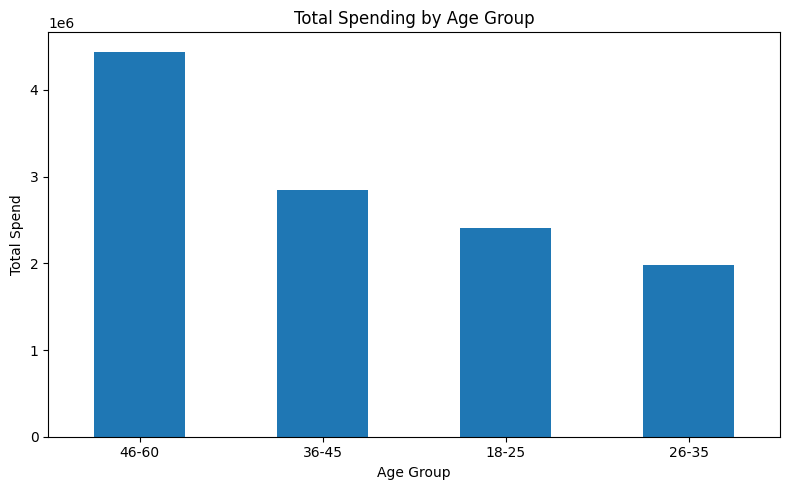

In [ ]:
plt.figure(figsize=(8, 5))
age_spend.plot(kind="bar")
plt.title("Total Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Spend")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

2.TOTAL SPEND BY LOCATION

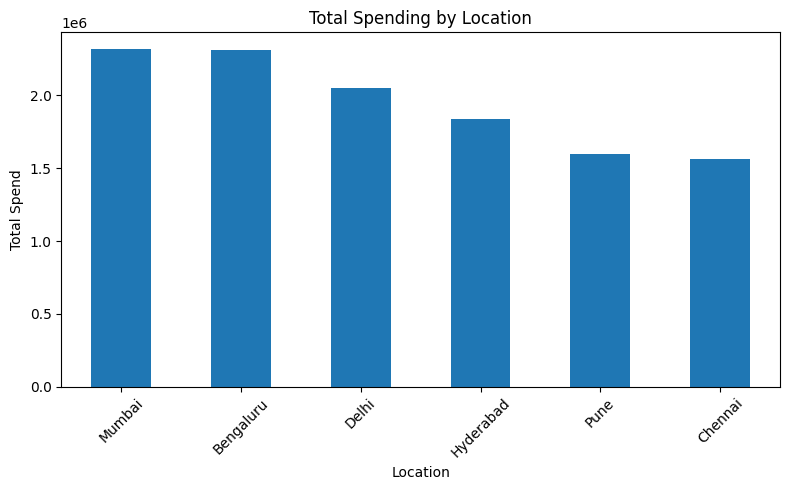

In [ ]:
plt.figure(figsize=(8, 5))
location_spend.plot(kind="bar")
plt.title("Total Spending by Location")
plt.xlabel("Location")
plt.ylabel("Total Spend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

3.TOTAL SPEND BY PRODUCT CATEGORY

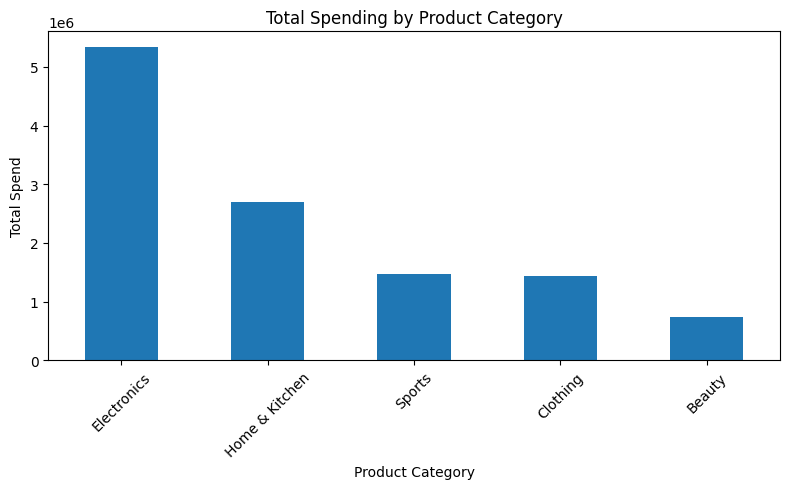

In [ ]:
plt.figure(figsize=(8, 5))
category_spend.plot(kind="bar")
plt.title("Total Spending by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Spend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

4.CUSTOMER SPEND BAND


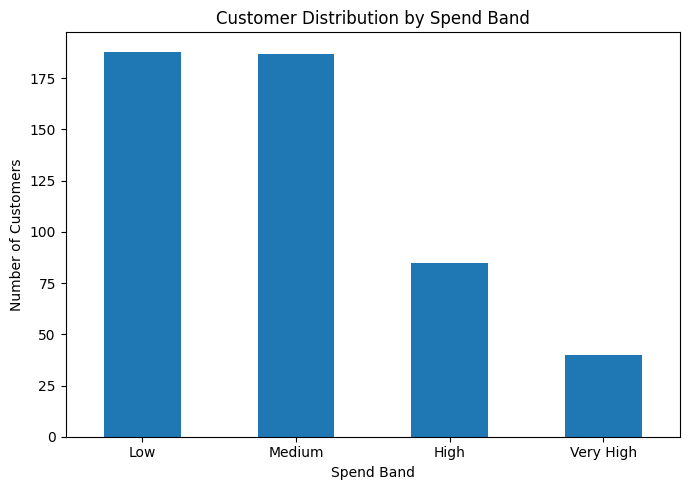

In [ ]:
plt.figure(figsize=(7, 5))
df["Spend_Band"].value_counts().plot(kind="bar")
plt.title("Customer Distribution by Spend Band")
plt.xlabel("Spend Band")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

5.PURCHASE FREQUENCY

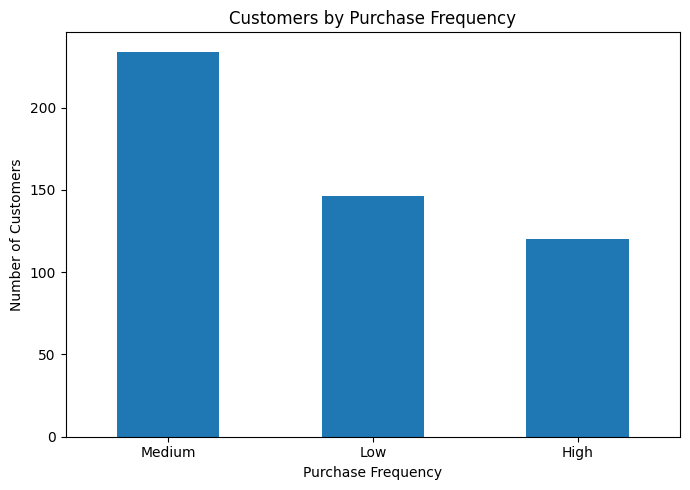

In [ ]:
plt.figure(figsize=(7, 5))
df["Purchase_Frequency"].value_counts().plot(kind="bar")
plt.title("Customers by Purchase Frequency")
plt.xlabel("Purchase Frequency")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

In [ ]:
df.to_csv('task4_analyzed_dataset.csv', index=False)
files.download('task4_analyzed_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>